In [1]:
# In[1]:


import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller


# In[2]:


print(np.tanh(5))


# In[3]:


import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
n = 30000

# Initialize arrays to store the time series
x = np.zeros(n)
y = np.zeros(n)
gyx = np.zeros(n)
gxy = np.zeros(n)


# In[2]:


# Generate random errors
e1 = np.random.normal(0, 0.1, n)
e2 = np.random.normal(0, 0.1, n)


0.9999092042625951


In [3]:
!pip install xlsxwriter
import xlsxwriter

Streaming output truncated to the last 5000 lines.
497.6841359368384 245.55753032896703 999.6582562272164 599.8890413178142
497.53122239603 245.4269984178793 999.722571699474 599.9978849357001
497.8672442007331 245.54238690628546 999.7507673130514 599.976452267423
497.86375745303724 245.46618672011937 999.8644285126602 600.1996594785828
497.82870742019395 245.4510120573359 1000.0181195148773 600.2465032375364
497.8649191966772 245.4516891481706 1000.0549385290135 600.3640606544551
497.8818274880789 245.73761904295452 1000.2272944062488 600.3462079898186
497.9924279074229 245.59875087268284 1000.0474580673886 600.3055681186928
498.01522930421936 245.7487974891339 1000.1357086167232 600.188962704638
498.00677172556243 245.7429702922526 1000.1257961342604 600.3197577048943
497.9358002474688 245.59375840235296 1000.2601444347657 600.3045908405871
497.8628420033715 245.67612029789188 1000.212740938818 600.2572597350113
498.0221766180654 245.60442851951387 1000.0434587461538 600.506694849587

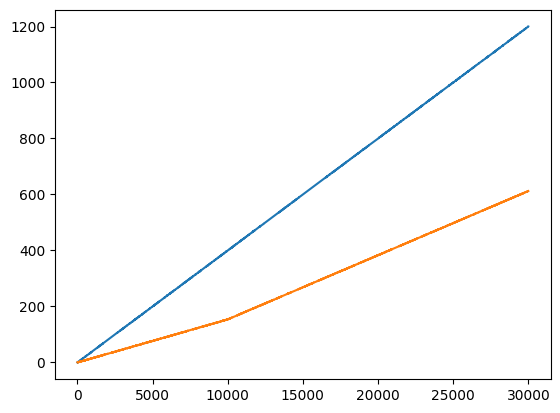

In [2]:
alpha_x = 0.75
alpha_y = 0.35
byx = 0.45
bxy = -1*0.35
dyx = 11000
dxy = 10000

x[0] = 0.5
y[0] = 0.5

for i in range(1,n):
    gyx[i] = 0
    gxy[i] = bxy*0.5*(1+np.tanh(0.05*(i-1000)))
    print(y[i-1], y[i-dyx], x[i-1], x[i-dxy])
    x[i] = 1*alpha_x*x[i-1] + 1*gyx[i]*y[i-dyx] + 1*e1[i] + i*0.01
    y[i] = alpha_y*y[i-1] + gxy[i]**2*x[i-dxy]**1 + 1*e2[i]  +i*0.01


# In[4]:


import matplotlib.pyplot as plt

plt.plot(x)
plt.plot(y)


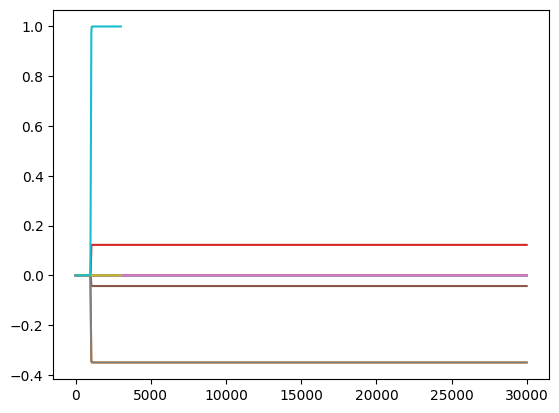

In [4]:
plt.plot(gyx**1)
plt.plot(gxy**1)


# In[6]:


plt.plot(gyx**2)
plt.plot(gxy**2)


# In[7]:


plt.plot(gyx**3)
plt.plot(gxy**3)


# In[8]:


plt.plot(gyx**1)
plt.plot(gxy**1)


# In[9]:


plt.plot(gyx[:3000]**1/(-0.35))
plt.plot(gxy[:3000]**1/(-0.35))


In [5]:
def _get_symbol_sequence(x,l,m):
    """ Convert a time series to a sequence of symbols

    args:
        :x (list or np.array) -- univariate time series
        :l (int) -- the time delay
        :m (int) -- the order (or symbol size)

    returns:
        :symbol sequence for time series x (numpy 2d array)
    """

    Y = np.empty((m, len(x) - (m - 1) * l))
    for i in range(m):
        Y[i] = x[i * l:i * l + Y.shape[1]]
    return Y.T

In [6]:
def incr_counts(key,d):
    """ Helper function for creating joint distribution over symbols.
    Joint distribution is built in a dictionary where d[key] gives the
    frequency of key.
    """
    if key in d:
        d[key] += 1
    else:
        d[key] = 1


In [7]:
def normalize(d):
    """ Helper function for creating joint distribution over symbols.
    Converts dictionary of raw counts to dictionary of probabilities in [0,1].
    """
    s=sum(d.values())
    for key in d:
        d[key] /= s



In [8]:

#l=3
#m=3
#q=1.003
import pandas as pd
#l=3
#m=3
#q=1.003

def map_magnitude(arr):
    sorted_indices = sorted(range(len(arr)), key=lambda k: arr[k])

    # Handle equal amplitude values by assigning them the same rank
    current_rank = 1
    rank_mapping = {}
    for i, idx in enumerate(sorted_indices):
        if i > 0 and arr[sorted_indices[i]] != arr[sorted_indices[i-1]]:
            current_rank += 1
        rank_mapping[idx] = current_rank

    mapped_array = [rank_mapping[i] for i in range(len(arr))]
    return mapped_array


import pandas as pd

In [9]:
def symbolic_TE_RE(ts1,ts2,l,m,q):
    """
        Calculate Symbolic Transfer Entropy between two univariate time series

        args:
            :ts1 (list or np.array) -- univariate time series
            :ts2 (list or np.array) -- univariate time series
            :l (int) -- the time delay
            :m (int) -- the order (or symbol size) ... e.g m=3 gives symbols such as [0,1,2]

        returns:
            :symbolic transfer entropy from ts1 to ts2 (float)

        notes:
            :x_sym --  the symbol sequence obtained from ts1 ... e.g. [[0,1,2],[1,2,0],...]
            :x_sym_to_perm -- maps each symbol in x_sym to a unique int ... e.g. [0,1,2] --> 1
            :p_xyy1 -- gives the joint distribution p(x_i= , y_i= , y_{i+1}= ) stored in a dictionary
                where a key is a string ... e.g. key="1,5,2" has value p(x_i=1, y_i=5, y_{i+1}=2)
            :p_xy, p_yy1, p_y -- respective marginal distributions
    """

    #x_sym = _get_symbol_sequence(ts1,l,m).argsort(kind='quicksort')
    #y_sym = _get_symbol_sequence(ts2,l,m).argsort(kind='quicksort')

    x_sym = [map_magnitude(vector) for vector in _get_symbol_sequence(ts1,l,m)]
    y_sym = [map_magnitude(vector) for vector in _get_symbol_sequence(ts2,l,m)]

    #print(mapped_magnitudes)

    hashmult = np.power(m, np.arange(m))
    hashval_x = (np.multiply(x_sym, hashmult)).sum(1)
    hashval_y = (np.multiply(y_sym, hashmult)).sum(1)

    x_sym_to_perm = hashval_x
    y_sym_to_perm = hashval_y

    p_xyy1 = {}
    p_xy = {}
    p_yy1 = {}
    p_y = {}
    #for i in range(len(y_sym_to_perm)):
    #    xy = str(x_sym_to_perm[i]) + "," + str(y_sym_to_perm[i])
    #    y = str(y_sym_to_perm[i])

    for i in range(len(y_sym_to_perm)-1):
        xyy1 = str(x_sym_to_perm[i]) + "," + str(y_sym_to_perm[i]) + "," + str(y_sym_to_perm[i+1])
        yy1 = str(y_sym_to_perm[i]) + "," + str(y_sym_to_perm[i+1])
        xy = str(x_sym_to_perm[i]) + "," + str(y_sym_to_perm[i])
        y = str(y_sym_to_perm[i])

        incr_counts(xyy1,p_xyy1)
        incr_counts(xy,p_xy)
        incr_counts(yy1,p_yy1)
        incr_counts(y,p_y)

    normalize(p_xyy1)
    normalize(p_xy)
    normalize(p_yy1)
    normalize(p_y)

#power sums
    p_y_i = p_y.copy()
    p_xy_i = p_xy.copy()

    p_y_sumq=0
    p_xy_sumq=0

    for y in p_y_i:
        p_y_sumq += pow(p_y[y],q)

    H_RE = (1/(1-q))*np.log2(p_y_sumq)
    #print("q: {}" .format(q))
    #print("p_y_sumq: {}".format(p_y_sumq))
    #print("H_RE: {}".format(H_RE))

    H_SE =0
    for y in p_y_i:
        H_SE +=  p_y[y]*np.log2(p_y[y])
    #print("H_SE: {}".format(-H_SE))


    for xy in p_xy_i:
        p_xy_sumq += pow(p_xy[xy],q)
    #print("p_xy_sumq: {}".format(p_xy_sumq))
    H_RE2 = (1/(1-q))*np.log2(p_xy_sumq)
    #print("H_RE2: {}".format(H_RE2))

    H_SE2 =0
    for xy in p_xy_i:
        H_SE2 +=  p_xy[xy]*np.log2(p_xy[xy])
    #print("H_SE2: {}".format(-H_SE2))



#conditional distributions
    p_y1_given_xy = p_xyy1.copy()
    for xyy1 in p_y1_given_xy:
        xy = xyy1.split(",")[0] + "," + xyy1.split(",")[1]
        p_y1_given_xy[xyy1] /= p_xy[xy]

    p_y1_given_y = p_yy1.copy()
    for yy1 in p_y1_given_y:
        y = yy1.split(",")[0]
        p_y1_given_y[yy1] /= p_y[y]

    pysumq = 0
    py1ysumq = 0
    p_y_sumq1 = 0
    for yy1 in p_y1_given_y:
        y = yy1.split(",")[0]
        pysumq += pow(p_y[y],q)
        p_y_sumq1 += pow(p_y[y],q)
        py1ysumq += pow(p_yy1[yy1],q)

    Hy1y_RE = np.log2(py1ysumq/p_y_sumq)/(1-q)

    #print("p_y_sumq: {}".format(pysumq))
    #print("p_y1y_sumq: {}".format(py1ysumq))
    #print("p_y_sumq1: {}".format(p_y_sumq1))
    #print("H_y1y_RE: {}".format(Hy1y_RE))

    Hy1y_SE =0
    Hy1y_SE1 =0
    for yy1 in p_y1_given_y:
        y = yy1.split(",")[0]
        Hy1y_SE += p_yy1[yy1]*np.log2(p_yy1[yy1]/p_y[y])
        Hy1y_SE1 += p_yy1[yy1]*np.log2(p_y1_given_y[yy1])

    #print("H_y1y_SE: {}".format(Hy1y_SE))
    #print("H_y1y_SE1: {}".format(Hy1y_SE1))

    #entropy calculation
    final_sum1 = 0
    final_sum2 = 0
    for xyy1 in p_xyy1:
        yy1 = xyy1.split(",")[1] + "," +  xyy1.split(",")[2]
        y = xyy1.split(",")[1]
        xy = xyy1.split(",")[0] + "," +  xyy1.split(",")[1]

        if xyy1 in p_y1_given_xy and yy1 in p_y1_given_y and y in p_y and xy in p_xy:
            if float('-inf') < float(np.log2(p_y1_given_xy[xyy1]/p_y1_given_y[yy1])) < float('inf'):

                #final_sum1 += 1*(pow(p_y[y],q)/(p_y_sumq))*pow(p_y1_given_y[yy1],q)
                final_sum2 += 1*(pow(p_xy[xy],q)/(p_xy_sumq))*pow(p_y1_given_xy[xyy1],q)

    for yy1 in p_yy1:
        y = yy1.split(",")[0]
        if yy1 in p_y1_given_y and y in p_y:
            if float('-inf') < float(np.log2(p_y1_given_y[yy1]/p_y[y])) < float('inf'):
                final_sum1 += 1*(pow(p_y[y],q)/(p_y_sumq))*pow(p_y1_given_y[yy1],q)

    final_sum = 0
    for xyy1 in p_xyy1:
        yy1 = xyy1.split(",")[1] + "," +  xyy1.split(",")[2]
        if xyy1 in p_y1_given_xy and yy1 in p_y1_given_y:
            if float('-inf') < float(np.log2(p_y1_given_xy[xyy1]/p_y1_given_y[yy1])) < float('inf'):
                final_sum += p_xyy1[xyy1]*np.log2(p_y1_given_xy[xyy1]/p_y1_given_y[yy1])

    #print("Final sum1: {}".format(final_sum1))
    #print("Final sum2: {}".format(final_sum2))

    #print((np.log2(final_sum1/final_sum2)))

    #print((np.log2(final_sum1/final_sum2))/(1-q))
    #print(final_sum)
    return (np.log2(final_sum1/final_sum2))/(1-q)

# In[15]:


#from copent import transent


# In[7]:


In [18]:
def _TDMI_DataFrame_tau_STE(t13, t23):
    """ Generate a causality DataFrame for a network

    args:
        :data (list or np.array) -- univariate time series
        :meta (int) -- the time delay


    returns:
        :DataFrame (numpy 2d array)
    """

    #tdmi = pd.DataFrame([])

    tdmi = {}
    temp_data = []

    qrange = np.arange(0.1,3.0,0.15)
    qrange[np.abs(qrange-1)<10e-6] = 0.999

    #lag_ran = range(1,26)
    tau = range(1,15001)

    #for m in range(2,10):
    for m in [3]:
        #for q in qrange:
        #for q in [0.1,0.5,1.5,2]:
        for q in [4]:
            #lag_ran = range(1,int(len(t13)/(m-1))-1)
            lag_ran = range(1,2)
            for lag in lag_ran:
                for t in range(len(tau)):
                    i = 0
                    #yis =  t13[bs[b]:]
                    #x1is = t23[0:-bs[b]]

                    #x_ms = multi_scale(tau[t],t13)
                    #y_ms = multi_scale(tau[t],t23)

                    #x1is = x_ms[tau[t]:]
                    #yis =  y_ms[0:-tau[t]]

                    x1is = t13[ tau[t]: ]
                    yis =  t23[0:-tau[t]]

                    #x1is = t13
                    #yis = t23

                    #print(np.shape(x_ms), np.shape(y_ms), tau[t], lag, m, q, np.shape(x1is), np.shape(yis))
                    print(np.shape(t13), np.shape(t23), tau[t], lag, m, q, np.shape(x1is), np.shape(yis))

                    #print(np.shape(t13), np.shape(t23), lag, m, q, np.shape(x1is), np.shape(yis))

                    #print(np.shape(t13), np.shape(t23), tau[t], lag, m, q)

                    #print(np.shape(t13), np.shape(t23), lag, m, q)

                    a1 =  symbolic_TE_RE(yis,x1is,lag,m=m,q=q)
                    #ordpy.permutation_entropy([yis,x1is], dx=m, dy=1, taux=lag, tauy=lag)
                    a2 =  symbolic_TE_RE(x1is,yis,lag,m=m,q=q)
                    a3 = a1 - a2
                    #a1.append(symbolic_TE_RE(t13,t23,lag,m=m,q=q))
                    print(a1)

                #te123[l, m, q, bs] = [a1,a2,a3]

                    #tdmi[lag, m, q, tau[t]] = [a1,a2,a3]


                    temp_data.append(((lag, m, q, tau[t]), [a1, a2, a3]))
                    for key, value in temp_data:
                        tdmi[key] = value

                    #tdmi[lag, m, q] = [a1,a2,a3]


    #tdmi[bs[b]] = a3
    del a1, a2, a3, yis, x1is


    #tdmi.index = lag_ran
    return tdmi


In [16]:
#from copent import transent

def _TDMI_DataFrame_tau_STE1(t13, t23):
    """ Generate a causality DataFrame for a network

    args:
        :data (list or np.array) -- univariate time series
        :meta (int) -- the time delay


    returns:
        :DataFrame (numpy 2d array)
    """

    #tdmi = pd.DataFrame([])

    tdmi = {}
    temp_data = []

    qrange = np.arange(0.1,3.0,0.15)
    qrange[np.abs(qrange-1)<10e-6] = 0.999

    #lag_ran = range(1,26)
    #tau = range(1,15000)
    tau = range(9800,10200)

    #for m in range(2,10):
    for m in [3]:
        #for q in qrange:
        #for q in [0.1,0.5,1.5,2]:
        for q in [4]:
            #lag_ran = range(1,int(len(t13)/(m-1))-1)
            lag_ran = range(1,2)
            for lag in lag_ran:
                for t in range(len(tau)):
                    i = 0
                    #yis =  t13[bs[b]:]
                    #x1is = t23[0:-bs[b]]

                    #x_ms = multi_scale(tau[t],t13)
                    #y_ms = multi_scale(tau[t],t23)

                    #x1is = x_ms[tau[t]:]
                    #yis =  y_ms[0:-tau[t]]

                    x1is = t13[ 0:-tau[t]  ]
                    yis =  t23[tau[t]:]

                    #x1is = t13
                    #yis = t23

                    #print(np.shape(x_ms), np.shape(y_ms), tau[t], lag, m, q, np.shape(x1is), np.shape(yis))
                    print(np.shape(t13), np.shape(t23), tau[t], lag, m, q, np.shape(x1is), np.shape(yis))

                    #print(np.shape(t13), np.shape(t23), lag, m, q, np.shape(x1is), np.shape(yis))

                    #print(np.shape(t13), np.shape(t23), tau[t], lag, m, q)

                    #print(np.shape(t13), np.shape(t23), lag, m, q)

                    a1 =  symbolic_TE_RE(yis,x1is,lag,m=m,q=q)
                    #ordpy.permutation_entropy([yis,x1is], dx=m, dy=1, taux=lag, tauy=lag)
                    a2 =  symbolic_TE_RE(x1is,yis,lag,m=m,q=q)
                    a3 = a1 - a2
                    #a1.append(symbolic_TE_RE(t13,t23,lag,m=m,q=q))
                    print(a1)

                #te123[l, m, q, bs] = [a1,a2,a3]
                    #tdmi[lag, m, q, tau[t]] = [a1,a2,a3]


                    temp_data.append(((lag, m, q, tau[t]), [a1, a2, a3]))

                    for key, value in temp_data:
                        tdmi[key] = value


                    #tdmi[lag, m, q] = [a1,a2,a3]


    #tdmi[bs[b]] = a3
    del a1, a2, a3, yis, x1is


    #tdmi.index = lag_ran
    return tdmi


# In[17]:


TDMI_tau_2b_data1 = {}
TDMI_tau_2b_data2 = {}


In [12]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

TDMI_tau_2b_data1 = {}
TDMI_tau_2b_data2 = {}
correlation_12 = {}


In [13]:
TDMI_tau_2b_data1_MIR = {}
TDMI_tau_2b_data2_MIR = {}
correlation_12 = {}
xy_data = {}

In [ ]:
from scipy.stats import pearsonr


# In[10]:


for j in range(2):
    #n = 15000



    n = 30000

    # Initialize arrays to store the time series
    x = np.zeros(n)
    y = np.zeros(n)
    gyx = np.zeros(n)
    gxy = np.zeros(n)


    # Initialize arrays to store the time series
    x = np.zeros(n)
    y = np.zeros(n)

    # Generate random errors
    e1 = np.random.normal(0, 0.1, n)
    e2 = np.random.normal(0, 0.1, n)

    # Introduce a linear trend to make the AR process non-stationary
    #trend = np.linspace(0, 2, n)  # Linearly increasing trend
    #x[0] = 0.5

    # Generate the time series
    #for t in range(1, n):
    #    x[t] = c1 * y[t-30]**1 + trend[t] + e1[t]
    #    y[t] = c2 * x[t-70]**1  + e2[t]


    # Generate random errors
    #e1 = np.random.normal(0, 0.1, n)
    #e2 = np.random.normal(0, 0.1, n)


    alpha_x = 0.75
    alpha_y = 0.35
    byx = -0.4
    bxy = -1*0.35
    dyx = 11000
    dxy = 10000

    x[0] = 0.5
    y[0] = 0.5

    for i in range(1,n):
        gyx[i] = 0
        gxy[i] = bxy*0.5*(1+np.tanh(0.05*(i-1000)))
        #print(y[i-1], y[i-dyx], x[i-1], x[i-dxy])
        x[i] = 1*alpha_x*x[i-1] + 1*gyx[i]*y[i-dyx] + 1*e1[i] + i*0.01
        y[i] = alpha_y*y[i-1] + gxy[i]**2*x[i-dxy]**1 + 1*e2[i]  +i*0.01

    # Perform ADF test
    result_x = adfuller(x)
    result_y = adfuller(y)
    print(j)
    print("ADF test results for x:")
    print(f"ADF Statistic: {result_x[0]}")
    print(f"p-value: {result_x[1]}")
    print("Critical Values:")
    for key, value in result_x[4].items():
        print(f"{key}: {value}")

    print("\nADF test results for y:")
    print(f"ADF Statistic: {result_y[0]}")
    print(f"p-value: {result_y[1]}")
    print("Critical Values:")
    for key, value in result_y[4].items():
        print(f"{key}: {value}")

    # Z-score the time series
    #zscore_x = (x - np.mean(x)) / np.std(x)
    #zscore_y = (y - np.mean(y)) / np.std(y)

    zscore_x = x
    zscore_y = y

    # Perform ADF test on z-scored time series
    result_zscore_x = adfuller(zscore_x)
    result_zscore_y = adfuller(zscore_y)

    #TDMI_tau_2b_data1_MIR[j] = _TDMI_DataFrame_tau_MIR(zscore_x, zscore_y)
    #TDMI_tau_2b_data2_MIR[j] = _TDMI_DataFrame_tau_MIR_1(zscore_x, zscore_y)
    xy_data[j] = pd.DataFrame({'time_index': range(n), 'x': x.copy(), 'y': y.copy()})
    TDMI_tau_2b_data1[j] = _TDMI_DataFrame_tau_STE(zscore_x, zscore_y)
    TDMI_tau_2b_data2[j] = _TDMI_DataFrame_tau_STE1(zscore_x, zscore_y)


    max_lag = 15000
    lagged_corr = []
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            corr, _ = pearsonr(zscore_x[:lag], zscore_y[-lag:])
        elif lag > 0:
            corr, _ = pearsonr(zscore_x[lag:], zscore_y[:-lag])
        else:
            corr, _ = pearsonr(zscore_x, zscore_y)

        lagged_corr.append(corr)

    correlation_12[j] = lagged_corr

    #plt.plot(range(-max_lag, max_lag + 1), lagged_corr)

    #print(TDMI_tau_2b_data1[i])
    print(correlation_12)





0
ADF test results for x:
ADF Statistic: 0.023594609429688652
p-value: 0.9604403882468197
Critical Values:
1%: -3.430568366575669
5%: -2.8616365121178777
10%: -2.5668213704562017

ADF test results for y:
ADF Statistic: 16.56332087001991
p-value: 1.0
Critical Values:
1%: -3.430568366575669
5%: -2.8616365121178777
10%: -2.5668213704562017
(30000,) (30000,) 1 1 3 4 (29999,) (29999,)
0.01618405540510774
(30000,) (30000,) 2 1 3 4 (29998,) (29998,)
0.005701187824797606
(30000,) (30000,) 3 1 3 4 (29997,) (29997,)
-0.0037526934077141503
(30000,) (30000,) 4 1 3 4 (29996,) (29996,)
-0.00269075263925387
(30000,) (30000,) 5 1 3 4 (29995,) (29995,)
-0.030734964553016383
(30000,) (30000,) 6 1 3 4 (29994,) (29994,)
0.002617449898986497
(30000,) (30000,) 7 1 3 4 (29993,) (29993,)
0.01042856950738521
(30000,) (30000,) 8 1 3 4 (29992,) (29992,)
0.016332462164730804
(30000,) (30000,) 9 1 3 4 (29991,) (29991,)
-0.009129753683356638
(30000,) (30000,) 10 1 3 4 (29990,) (29990,)
-0.017615138546948263
(30000,

In [ ]:
print(TDMI_tau_2b_data1)

{0: {(1, 3, 4, 10800): [np.float64(0.013841624843872814), np.float64(0.00020143736688778714), np.float64(0.013640187476985026)], (1, 3, 4, 10801): [np.float64(-0.012545336123242622), np.float64(0.0004708558728105285), np.float64(-0.01301619199605315)], (1, 3, 4, 10802): [np.float64(-0.0071588487915653755), np.float64(0.01050331957930156), np.float64(-0.017662168370866937)], (1, 3, 4, 10803): [np.float64(0.0222734460976359), np.float64(-0.0006773014596423948), np.float64(0.022950747557278297)], (1, 3, 4, 10804): [np.float64(0.019425690174365753), np.float64(-0.008344838272604703), np.float64(0.027770528446970456)], (1, 3, 4, 10805): [np.float64(0.02617286036485879), np.float64(0.001352508661230236), np.float64(0.024820351703628556)], (1, 3, 4, 10806): [np.float64(0.012511163887505415), np.float64(0.019207702078651002), np.float64(-0.006696538191145587)], (1, 3, 4, 10807): [np.float64(-0.008548588034564151), np.float64(0.0129378310798148), np.float64(-0.02148641911437895)], (1, 3, 4, 108

In [ ]:
from google.colab import files

In [ ]:
import pandas as pd

data_dict = TDMI_tau_2b_data1
xy_dict = xy_data

excel_file = 'Efficient_Paper_Synthetic_Data_1.xlsx'

with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    # --- Write TDMI data ---
    for key, value in data_dict.items():
        try:
            df = pd.DataFrame(value)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = ['_'.join(map(str, col)).strip() for col in df.columns.values]
            sheet_name = f'Sheet_{key}'
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"TDMI data for key '{key}' has been successfully written to the Excel file.")
        except Exception as e:
            print(f"Failed to write TDMI data for key '{key}' to the Excel file.")
            print(f"Error: {e}")

    # --- Write x, y synthetic data (one sheet per trial j) ---
    for key, df_xy in xy_dict.items():
        try:
            sheet_name = f'XY_{key}'
            df_xy.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"x,y data for trial '{key}' has been successfully written to the Excel file.")
        except Exception as e:
            print(f"Failed to write x,y data for trial '{key}' to the Excel file.")
            print(f"Error: {e}")

print("All data has been written to the Excel file.")
files.download(excel_file)

TDMI data for key '0' has been successfully written to the Excel file.
x,y data for trial '0' has been successfully written to the Excel file.
x,y data for trial '1' has been successfully written to the Excel file.
All data has been written to the Excel file.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

data_dict = TDMI_tau_2b_data2
xy_dict = xy_data

excel_file = 'Efficient_Paper_Synthetic_Data_2.xlsx'

with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    # --- Write TDMI data ---
    for key, value in data_dict.items():
        try:
            df = pd.DataFrame(value)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = ['_'.join(map(str, col)).strip() for col in df.columns.values]
            sheet_name = f'Sheet_{key}'
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"TDMI data for key '{key}' has been successfully written to the Excel file.")
        except Exception as e:
            print(f"Failed to write TDMI data for key '{key}' to the Excel file.")
            print(f"Error: {e}")

    # --- Write x, y synthetic data (one sheet per trial j) ---
    for key, df_xy in xy_dict.items():
        try:
            sheet_name = f'XY_{key}'
            df_xy.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"x,y data for trial '{key}' has been successfully written to the Excel file.")
        except Exception as e:
            print(f"Failed to write x,y data for trial '{key}' to the Excel file.")
            print(f"Error: {e}")

print("All data has been written to the Excel file.")
files.download(excel_file)

TDMI data for key '0' has been successfully written to the Excel file.
x,y data for trial '0' has been successfully written to the Excel file.
x,y data for trial '1' has been successfully written to the Excel file.
All data has been written to the Excel file.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Assuming correlation_12 is a list of lists
correlation_12_df = pd.DataFrame(correlation_12)

# Now you can save correlation_12_df to an Excel file
correlation_12_df.to_excel("correlation_12.xlsx", index=False)